# Module 3: Training Loop End-to-End Test (v8 PPO pipeline)

Runs the full v8 PPO learning pipeline on a **tiny** system (3x3 lattice, 3 atoms dropped, ~6 atoms in King's lattice connectivity) to verify that the policy can learn schedules exceeding the fixed adiabatic baseline.

The earlier REINFORCE configuration in this notebook hit a pathological convergence: the gradient norm shrank toward zero while reward stayed flat. Root cause: the v8 `ControlsConfig` default `residual_alpha_start=0.05` was never annealed by the bare `reinforce_step` loop, freezing the policy at 5 % of its head deviation from the baseline (≈ no learning signal above shot noise). The EMA baseline then quickly absorbed what little advantage remained.

This rewritten version uses the v8 PPO step (`module3/ppo.py`) with:

* **Paired-baseline advantages** — `A(G) = r_learned(G) − r_baseline(G)`, one cached baseline call per graph.
* **K rollouts per graph** for variance reduction.
* **Per-graph normalized rewards** (`is_cost_vs_baseline`) so the gradient signal is "fractional improvement over adiabatic baseline".
* **Residual-α curriculum** explicitly annealed in the training loop (0.3 → 1.0 over 20 steps).

This is a functional test, not a research run.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch

from config import (
    ProjectConfig, ControlsConfig, UDGConfig, HardwareSpecs,
    ParamKind, RewardConfig, project_config_from_dict,
)
from graphs.unit_disk import generate_square_lattice_udg
from module1.policy import SchedulePolicy
from module1.base import FixedScheduleBaseline
from module2.braket_backend import BraketBackend
from module3.backend_adapter import (
    make_reward_fn, make_raw_reward_fn, BaselineRewardCache,
)
from module3.interfaces import TrainingConfig
from module3.ppo import ppo_step

## 1. Build a tiny config (3x3, King's lattice, ~6 atoms)

Tiny graph: 6 nodes, 9 edges
Approx MIS size: 2


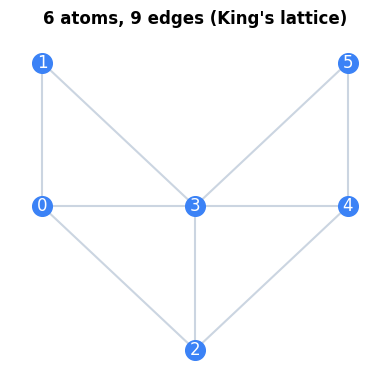

In [2]:
# King's lattice: radius = sqrt(2) in units of spacing connects diagonals
# spacing = 5.0 um gives R_b/a ≈ 1.67 — blockades diagonals but NOT (2,0) neighbors,
# so the quantum MIS matches the graph-theoretic MIS on the King's lattice.
tiny_cfg = ProjectConfig(
    backend="bloqade",
    controls=ControlsConfig(
        T=4.0e-6,
        N_t=32,
        param_kind=ParamKind.pwl,
        learn_omega=True,
        architecture=1,
        omega_max=15.8,
        delta_min=-25.0,
        delta_max=25.0,
        n_delta_modes=6,
    ),
    udg=UDGConfig(
        nx=3, ny=3,
        spacing=5.0,
        radius=1.5,         # sqrt(2) < 1.5 — captures diagonals = King's graph
        dropout_rate=1/3,   # drop 3 of 9 = keep 6
        seed=42,
    ),
    hardware=HardwareSpecs(
        C6=5.42e6,
        omega_max=15.8,
        delta_min=-125.0,
        delta_max=125.0,
        t_ramp=0.4,
        t_onset=0.2,
    ),
)

# Verify graph is sensible
G_test, pos_test = generate_square_lattice_udg(tiny_cfg.udg)
print(f"Tiny graph: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")
print(f"Approx MIS size: {len(nx.algorithms.approximation.maximum_independent_set(G_test))}")

fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G_test, pos_test, ax=ax, with_labels=True,
        node_color="#3b82f6", node_size=200, font_color="white",
        edge_color="#cbd5e1", width=1.5)
ax.set_title(f"{G_test.number_of_nodes()} atoms, {G_test.number_of_edges()} edges (King's lattice)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Measure baseline p_MIS

In [3]:
N_SHOTS = 500

backend = BraketBackend(tiny_cfg, n_shots=N_SHOTS, backend_type="simulator", validate=True)

# v8 reward setup
# raw_reward_fn returns un-normalized weighted-IS-cost rewards;
# reward_fn returns per-graph normalized improvement-over-baseline
# (the recommended training signal). Both share one BaselineRewardCache
# that runs the simulator on the analytic baseline exactly once per graph.
reward_cfg = RewardConfig(kind="is_cost_vs_baseline", penalty_U=3.0,
                          normalize_by_nodes=True, baseline_norm_eps=1e-3)

baseline_model = FixedScheduleBaseline(tiny_cfg)
raw_reward_fn = make_raw_reward_fn(backend, reward_cfg=reward_cfg)
baseline_cache = BaselineRewardCache(
    lambda G: raw_reward_fn(G, baseline_model.make_schedule(G))
)
reward_fn = make_reward_fn(
    backend, reward_cfg=reward_cfg, baseline_cache=baseline_cache,
)

# Attach positions for the reward function
G_test.graph["positions"] = pos_test

baseline_sched = baseline_model.make_schedule(G_test)
t0 = time.time()
baseline_result = backend.estimate_p_mis(baseline_sched, G_test, pos_test)
print(f"\nBaseline p_MIS = {baseline_result.p_mis:.2%} \u00b1 {baseline_result.std_err:.2%}  "
      f"({baseline_result.shots} shots, {time.time()-t0:.1f}s)")

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.7 s

Baseline p_MIS = 0.60% ± 0.35%  (500 shots, 12.9s)


## 3. Build training graph pool

Use a small pool of tiny graphs with different dropout seeds.

In [4]:
POOL_SIZE = 8
pool = []
for i in range(POOL_SIZE * 2):  # generate extras in case some have 0 edges
    udg_i = UDGConfig(
        nx=3, ny=3, spacing=5.0, radius=1.5,
        dropout_rate=1/3, seed=100 + i,
    )
    G, pos = generate_square_lattice_udg(udg_i)
    if G.number_of_edges() == 0:
        continue
    G.graph["positions"] = pos
    G.graph["seed"] = 100 + i
    pool.append(G)
    if len(pool) >= POOL_SIZE:
        break

print(f"Training pool: {len(pool)} graphs")
for G in pool:
    print(f"  seed={G.graph['seed']}: {G.number_of_nodes()}n, {G.number_of_edges()}e")

Training pool: 8 graphs
  seed=100: 6n, 8e
  seed=101: 6n, 10e
  seed=102: 6n, 5e
  seed=103: 6n, 10e
  seed=104: 6n, 7e
  seed=105: 6n, 9e
  seed=106: 6n, 9e
  seed=107: 6n, 10e


## 4. Run the PPO training loop (v8 pipeline)

Manual loop (not the full `TrainingOrchestrator`) so we can track and plot everything inline. Uses the v8 PPO step with:

* **Paired-baseline advantages** — `A(G) = r_learned(G) − r_baseline(G)`, one baseline call per graph (cached).
* **K rollouts per graph** — averages out simulator shot noise.
* **Advantage normalization** — zero-mean / unit-variance within each gradient step.
* **Residual-α curriculum** — schedule starts in a tight neighborhood of the baseline (α=0.3) and is linearly annealed to α=1.0 over the first 20 steps. Without this the bare `reinforce_step` runs with α=0.05 (the config default) the whole time, freezing the policy at the baseline.

The reward signal is `is_cost_vs_baseline` (per-graph fractional improvement over the analytic baseline) — so a positive `mean_reward` here means "policy is beating baseline on average".

In [5]:
import random

# ── Training hyperparameters ────────────────────────────────────────
TOTAL_STEPS = 100
BATCH_SIZE = 10
LR = 3e-4
EVAL_EVERY = 5

# PPO knobs
ROLLOUTS_PER_GRAPH = 3   # K rollouts/graph — variance ↓ K× per graph
PPO_EPOCHS = 4
PPO_CLIP = 0.2
PPO_MINIBATCH = 16

# Residual-α curriculum (linear from α_START → α_END over ALPHA_WARMUP steps).
# Bare REINFORCE froze the policy at α=0.05; we open it up faster.
ALPHA_START = 0.3
ALPHA_END = 1.0
ALPHA_WARMUP = 20

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

policy = SchedulePolicy(tiny_cfg, hidden_dim=32, init_log_std=-0.5)
optimizer = torch.optim.Adam(policy.parameters(), lr=LR)

# Set initial residual-α explicitly so we are NOT stuck at the default 0.05.
policy.set_residual_alpha(ALPHA_START)

# Pre-fill the baseline cache so the first PPO step doesn't pay 8 sim calls.
print(f"Pre-filling baseline cache on {len(pool)} pool graphs...")
t0 = time.time()
for G in pool:
    _ = baseline_cache.get(G)
print(f"  ...done in {time.time()-t0:.1f}s. Cache size: {len(baseline_cache)}")

n_params = sum(p.numel() for p in policy.parameters())
print(f"\nPolicy: {n_params:,} parameters")
print(f"Algorithm: PPO + paired baselines + advantage normalization")
print(f"  rollouts_per_graph={ROLLOUTS_PER_GRAPH}, clip={PPO_CLIP}, epochs={PPO_EPOCHS}")
print(f"  α schedule: {ALPHA_START} → {ALPHA_END} linearly over {ALPHA_WARMUP} steps")
print(f"Training: {TOTAL_STEPS} steps, batch={BATCH_SIZE}, lr={LR}")
print(f"Eval every {EVAL_EVERY} steps on {len(pool)} graphs")
print("=" * 70)

Pre-filling baseline cache on 8 pool graphs...
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.9 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.8 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.1 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.7 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.9 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.3 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.5 s
  ...done in 15.7s. Cache size: 8

Policy: 22,458 parameters
Algorithm: PPO + paired baselines + advantage normal

In [6]:
train_history = []
eval_history = []

def _scheduled_alpha(step: int) -> float:
    """Linear α schedule: ALPHA_START → ALPHA_END over ALPHA_WARMUP steps."""
    if ALPHA_WARMUP <= 0:
        return ALPHA_END
    frac = min(max(step / float(ALPHA_WARMUP), 0.0), 1.0)
    return ALPHA_START + frac * (ALPHA_END - ALPHA_START)


total_t0 = time.time()

for step in range(1, TOTAL_STEPS + 1):
    # Advance residual-α curriculum BEFORE collecting rollouts so this
    # step's actions are sampled under the new trust region.
    alpha = _scheduled_alpha(step - 1)
    policy.set_residual_alpha(alpha)

    batch = random.sample(pool, min(BATCH_SIZE, len(pool)))

    t0 = time.time()
    metrics = ppo_step(
        policy=policy,
        graphs=batch,
        backend_fn=reward_fn,            # normalized: is_cost_vs_baseline
        optimizer=optimizer,
        baseline_model=baseline_model,   # paired-baseline source
        raw_backend_fn=raw_reward_fn,    # raw is_cost for baseline eval
        rollouts_per_graph=ROLLOUTS_PER_GRAPH,
        ppo_epochs=PPO_EPOCHS,
        ppo_minibatch_size=PPO_MINIBATCH,
        ppo_clip=PPO_CLIP,
        entropy_coef=0.01,
        value_loss_coef=0.25,
        grad_clip=1.0,
        use_paired_baseline=True,
        advantage_normalization=True,
    )
    metrics["step"] = step
    metrics["alpha"] = alpha
    metrics["wall_time"] = time.time() - t0
    train_history.append(metrics)

    print(f"step {step:3d} | r {metrics['mean_reward']:+.3f} (vs base {metrics['mean_baseline_reward']:+.3f}) | "
          f"adv {metrics['mean_advantage']:+.3f} | "
          f"loss {metrics['loss']:+.4f} | ent {metrics['mean_entropy']:.2f} | "
          f"kl {metrics['approx_kl']:+.3f} | clip {metrics['clip_frac']:.2f} | "
          f"grad {metrics['grad_norm']:.2f} | α {alpha:.2f} | {metrics['wall_time']:.1f}s")

    # Periodic evaluation (deterministic; raw is_cost so numbers are
    # comparable to other notebooks).
    if step % EVAL_EVERY == 0:
        policy.eval()
        learned_rewards, baseline_rewards_eval = [], []
        for G in pool:
            sched_l = policy.make_schedule(G)
            r_l = raw_reward_fn(G, sched_l)
            learned_rewards.append(r_l)

            sched_b = baseline_model.make_schedule(G)
            r_b = raw_reward_fn(G, sched_b)
            baseline_rewards_eval.append(r_b)
        policy.train()

        eval_entry = {
            "step": step,
            "learned_mean": np.mean(learned_rewards),
            "learned_std": np.std(learned_rewards),
            "baseline_mean": np.mean(baseline_rewards_eval),
            "baseline_std": np.std(baseline_rewards_eval),
        }
        eval_history.append(eval_entry)
        print(f"  EVAL | learned {eval_entry['learned_mean']:.3f} \u00b1 {eval_entry['learned_std']:.3f} | "
              f"baseline {eval_entry['baseline_mean']:.3f} \u00b1 {eval_entry['baseline_std']:.3f} | "
              f"improvement {eval_entry['learned_mean'] - eval_entry['baseline_mean']:+.3f}")

total_time = time.time() - total_t0
print(f"\nDone. Total wall time: {total_time/60:.1f} min")

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.9 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.9 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.2 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.4 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.0 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.6 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.9 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.6 s
BraketBackend: running LocalSimulator — 500 shots, bloc

## 5. Learning curves

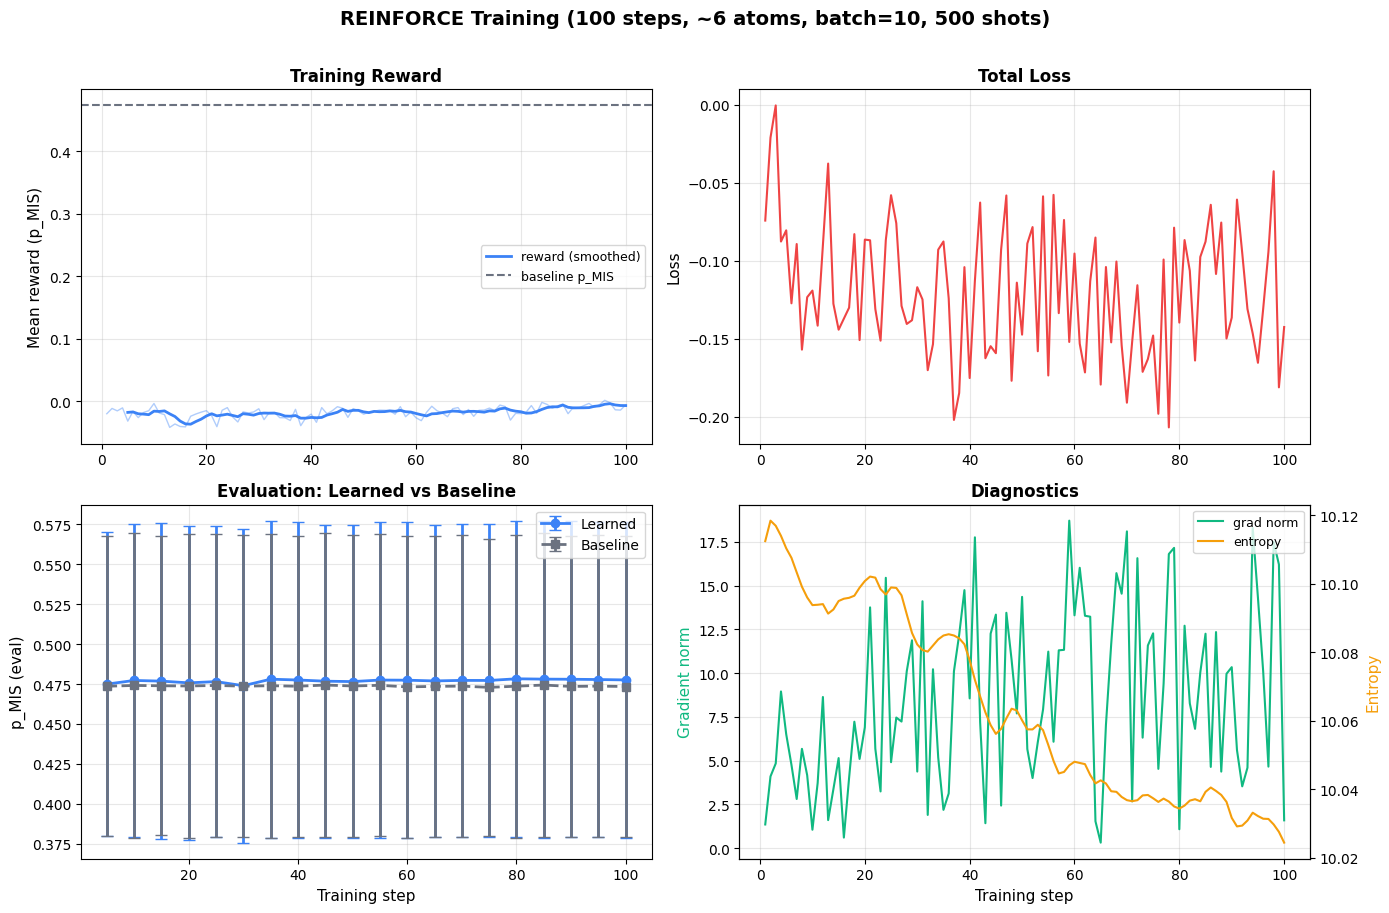

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

steps = [m["step"] for m in train_history]

# --- Panel 1: Training reward ---
ax = axes[0, 0]
rewards = [m["mean_reward"] for m in train_history]
ax.plot(steps, rewards, color="#3b82f6", alpha=0.4, linewidth=1)
# Smoothed
window = min(5, len(rewards))
if window > 1:
    smoothed = np.convolve(rewards, np.ones(window)/window, mode="valid")
    ax.plot(steps[window-1:], smoothed, color="#3b82f6", linewidth=2, label="reward (smoothed)")
# Baseline reference
if eval_history:
    ax.axhline(eval_history[-1]["baseline_mean"], color="#6b7280", linestyle="--",
               linewidth=1.5, label="baseline p_MIS")
ax.set_ylabel("Mean reward (p_MIS)", fontsize=11)
ax.set_title("Training Reward", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Panel 2: Loss ---
ax = axes[0, 1]
ax.plot(steps, [m["loss"] for m in train_history], color="#ef4444", linewidth=1.5)
ax.set_ylabel("Loss", fontsize=11)
ax.set_title("Total Loss", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# --- Panel 3: Eval learned vs baseline ---
ax = axes[1, 0]
if eval_history:
    e_steps = [e["step"] for e in eval_history]
    e_learned = [e["learned_mean"] for e in eval_history]
    e_learned_std = [e["learned_std"] for e in eval_history]
    e_baseline = [e["baseline_mean"] for e in eval_history]
    e_baseline_std = [e["baseline_std"] for e in eval_history]

    ax.errorbar(e_steps, e_learned, yerr=e_learned_std, color="#3b82f6",
                marker="o", capsize=4, linewidth=2, label="Learned")
    ax.errorbar(e_steps, e_baseline, yerr=e_baseline_std, color="#6b7280",
                marker="s", capsize=4, linewidth=2, linestyle="--", label="Baseline")
ax.set_ylabel("p_MIS (eval)", fontsize=11)
ax.set_xlabel("Training step", fontsize=11)
ax.set_title("Evaluation: Learned vs Baseline", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Panel 4: Gradient norm + entropy ---
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(steps, [m["grad_norm"] for m in train_history], color="#10b981", linewidth=1.5, label="grad norm")
ax2.plot(steps, [m["mean_entropy"] for m in train_history], color="#f59e0b", linewidth=1.5, label="entropy")
ax.set_ylabel("Gradient norm", fontsize=11, color="#10b981")
ax2.set_ylabel("Entropy", fontsize=11, color="#f59e0b")
ax.set_xlabel("Training step", fontsize=11)
ax.set_title("Diagnostics", fontsize=12, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")
ax.grid(alpha=0.3)

fig.suptitle(f"REINFORCE Training ({TOTAL_STEPS} steps, ~{G_test.number_of_nodes()} atoms, "
             f"batch={BATCH_SIZE}, {N_SHOTS} shots)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 6. Compare final schedules: learned vs baseline

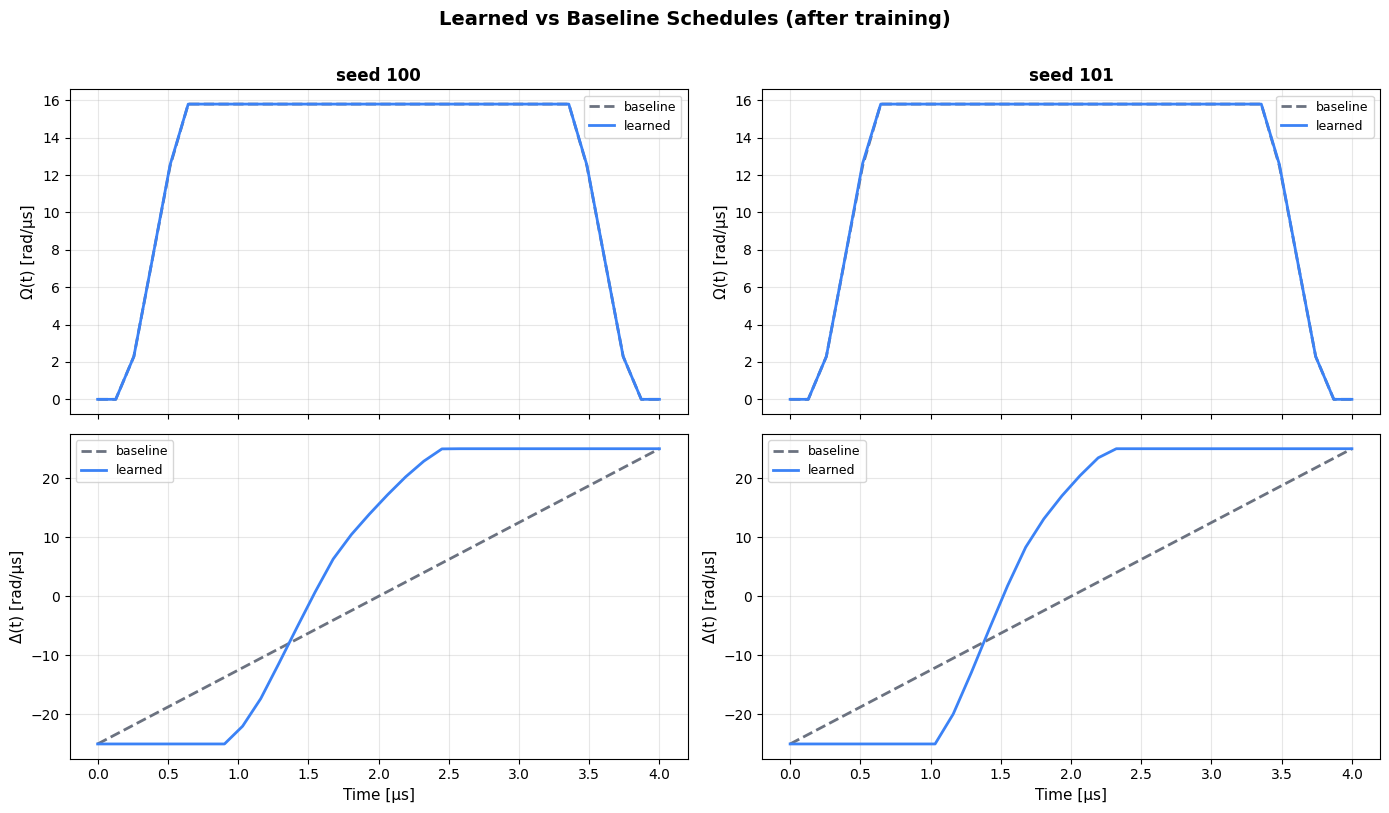

In [8]:
t_us = np.linspace(0, tiny_cfg.controls.T * 1e6, tiny_cfg.controls.N_t)

policy.eval()
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for col, G in enumerate(pool[:2]):
    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)
    seed = G.graph.get("seed", "?")

    axes[0, col].plot(t_us, sched_b.omega, color="#6b7280", linewidth=2,
                      linestyle="--", label="baseline")
    axes[0, col].plot(t_us, sched_l.omega, color="#3b82f6", linewidth=2,
                      label="learned")
    axes[0, col].set_ylabel("\u03a9(t) [rad/\u00b5s]", fontsize=11)
    axes[0, col].set_title(f"seed {seed}", fontsize=12, fontweight="bold")
    axes[0, col].legend(fontsize=9)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(t_us, sched_b.delta, color="#6b7280", linewidth=2,
                      linestyle="--", label="baseline")
    axes[1, col].plot(t_us, sched_l.delta, color="#3b82f6", linewidth=2,
                      label="learned")
    axes[1, col].set_ylabel("\u0394(t) [rad/\u00b5s]", fontsize=11)
    axes[1, col].set_xlabel("Time [\u00b5s]", fontsize=11)
    axes[1, col].legend(fontsize=9)
    axes[1, col].grid(alpha=0.3)

policy.train()

fig.suptitle("Learned vs Baseline Schedules (after training)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 7. Final evaluation with more shots

In [9]:
# Re-evaluate with more shots for cleaner p_MIS estimates
N_SHOTS_FINAL = 200
backend_final = BraketBackend(tiny_cfg, n_shots=N_SHOTS_FINAL, backend_type="simulator", validate=True)

policy.eval()
print(f"Final evaluation ({N_SHOTS_FINAL} shots per graph, {len(pool)} graphs)")
print("=" * 60)

final_learned, final_baseline = [], []
for G in pool:
    pos = G.graph["positions"]
    seed = G.graph.get("seed", "?")

    sched_l = policy.make_schedule(G)
    r_l = backend_final.estimate_p_mis(sched_l, G, pos)
    final_learned.append(r_l.p_mis)

    sched_b = baseline_model.make_schedule(G)
    r_b = backend_final.estimate_p_mis(sched_b, G, pos)
    final_baseline.append(r_b.p_mis)

    print(f"seed {seed}: learned={r_l.p_mis:.1%}  baseline={r_b.p_mis:.1%}  "
          f"diff={r_l.p_mis - r_b.p_mis:+.1%}")

policy.train()

print(f"\nMean learned:  {np.mean(final_learned):.1%} \u00b1 {np.std(final_learned):.1%}")
print(f"Mean baseline: {np.mean(final_baseline):.1%} \u00b1 {np.std(final_baseline):.1%}")
print(f"Mean improvement: {np.mean(np.array(final_learned) - np.array(final_baseline)):+.1%}")

Final evaluation (200 shots per graph, 8 graphs)
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …


BraketBackend: done in 1.4 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
seed 100: learned=98.0%  baseline=96.0%  diff=+2.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.2 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.8 s
seed 101: learned=100.0%  baseline=100.0%  diff=+0.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
seed 102: learned=98.0%  baseline=89.5%  diff=+8.5%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.5 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
seed 103: learned=98.5%  baseline=98.5%  diff=+0.0%
BraketBackend: running Loc

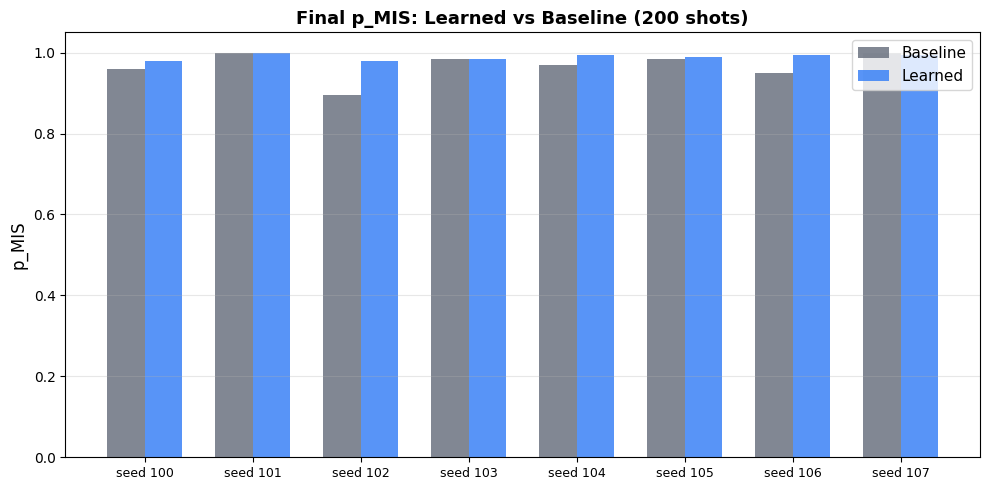

In [10]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pool))
width = 0.35

ax.bar(x - width/2, final_baseline, width, color="#6b7280", alpha=0.85, label="Baseline")
ax.bar(x + width/2, final_learned, width, color="#3b82f6", alpha=0.85, label="Learned")

ax.set_xticks(x)
ax.set_xticklabels([f"seed {G.graph.get('seed', '?')}" for G in pool], fontsize=9)
ax.set_ylabel("p_MIS", fontsize=12)
ax.set_title(f"Final p_MIS: Learned vs Baseline ({N_SHOTS_FINAL} shots)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()

## 8. Dashboard: Graph + MIS solutions + Schedules + Measurement outcomes

For each graph in the pool, a single row shows:
1. The atom arrangement with all exact MIS solutions overlaid
2. The learned vs baseline schedules (Omega and Delta)
3. The top-10 most-frequently measured node sets, color-coded by whether they are independent sets

In [11]:
from module2.graph_MIS_utils import get_all_MIS, check_independent_set
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# Pick a subset of graphs to display (up to 4 for readability)
display_graphs = pool[:4]
N_DISPLAY = len(display_graphs)

# Run high-shot simulations for both learned and baseline on each graph
# (reuses backend_final from cell above — 200 shots)
policy.eval()

display_data = []
for G in display_graphs:
    pos = G.graph["positions"]
    seed = G.graph.get("seed", "?")

    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)

    res_l = backend_final.estimate_p_mis(sched_l, G, pos)
    res_b = backend_final.estimate_p_mis(sched_b, G, pos)

    all_mis = get_all_MIS(G)

    display_data.append({
        "G": G, "pos": pos, "seed": seed,
        "sched_l": sched_l, "sched_b": sched_b,
        "res_l": res_l, "res_b": res_b,
        "all_mis": all_mis,
    })
    print(f"seed {seed}: {G.number_of_nodes()}n, {G.number_of_edges()}e, "
          f"{len(all_mis)} exact MIS solutions, "
          f"p_MIS learned={res_l.p_mis:.1%} baseline={res_b.p_mis:.1%}")

policy.train()

BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 2.1 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
seed 100: 6n, 8e, 3 exact MIS solutions, p_MIS learned=99.0% baseline=96.5%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
seed 101: 6n, 10e, 5 exact MIS solutions, p_MIS learned=100.0% baseline=100.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
seed 102: 6n, 5e, 1 exact MIS solutions, p_MIS learned=97.5% baseline=87.0%
BraketBackend: running LocalSimulator — 200 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimula

SchedulePolicy(
  (encoder): GINEncoder(
    (layers): ModuleList(
      (0): GINConv(nn=Sequential(
        (0): Linear(in_features=7, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      ))
      (1-2): 2 x GINConv(nn=Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
      ))
    )
  )
  (omega_head): OmegaHead(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=3, bias=True)
    )
  )
  (delta_head): DeltaHead(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=8, bias=True)
    )
  )
  (value_head): Sequential(
    (0): Linear(in_features=100, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features

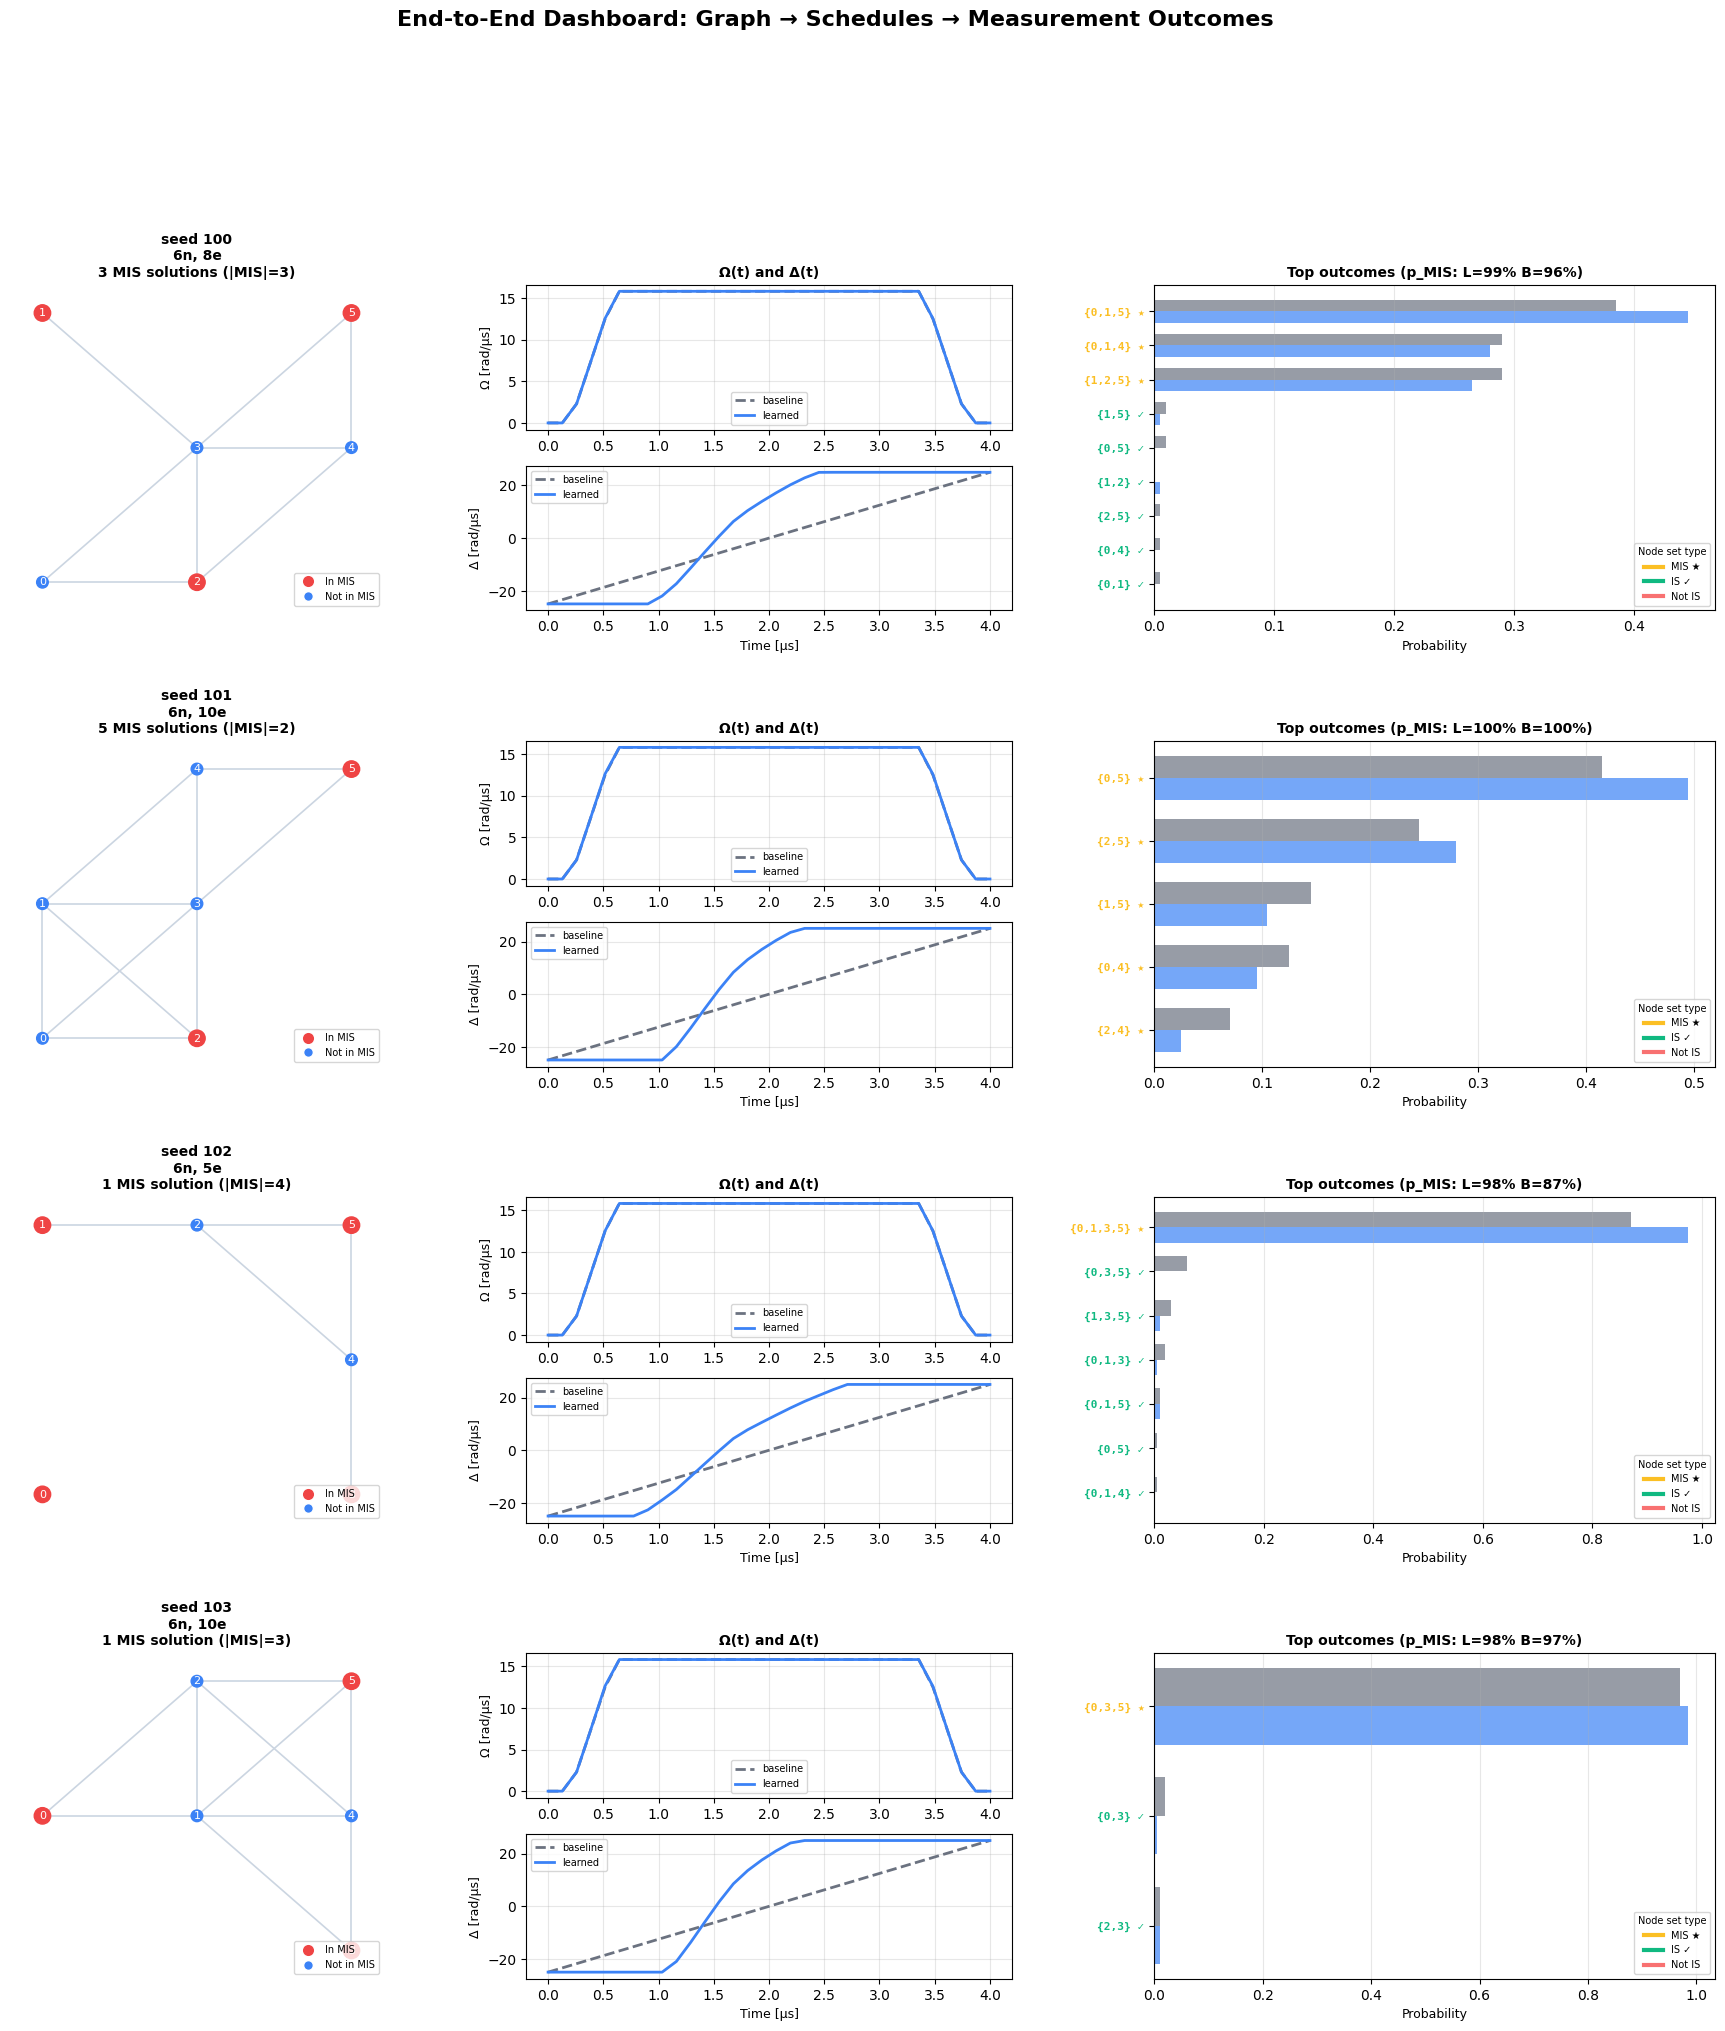

In [12]:
def _top_node_sets(counts, n_atoms, top_k=10):
    """Convert bitstring counts to sorted list of (node_set, count) tuples."""
    entries = []
    for bs, cnt in counts.items():
        nodes = frozenset(i for i, c in enumerate(bs) if c == 'r')
        entries.append((nodes, cnt))
    entries.sort(key=lambda x: -x[1])
    # Merge duplicate node sets (shouldn't happen but be safe)
    merged = {}
    for ns, cnt in entries:
        merged[ns] = merged.get(ns, 0) + cnt
    result = sorted(merged.items(), key=lambda x: -x[1])
    return result[:top_k]


fig = plt.figure(figsize=(22, 5.5 * N_DISPLAY))
outer = gridspec.GridSpec(N_DISPLAY, 1, hspace=0.4, figure=fig)

t_us = np.linspace(0, tiny_cfg.controls.T * 1e6, tiny_cfg.controls.N_t)

for row, d in enumerate(display_data):
    G, pos, seed = d["G"], d["pos"], d["seed"]
    all_mis = d["all_mis"]
    sched_l, sched_b = d["sched_l"], d["sched_b"]
    res_l, res_b = d["res_l"], d["res_b"]

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 3, subplot_spec=outer[row],
        wspace=0.3, hspace=0.25,
        width_ratios=[1, 1.3, 1.5],
    )

    # ── Column 0: Graph with MIS solutions ──
    ax_graph = fig.add_subplot(inner[:, 0])
    mis_union = set()
    for s in all_mis:
        mis_union = s
    node_list = sorted(G.nodes())
    nc = ["#ef4444" if n in mis_union else "#3b82f6" for n in node_list]
    ns = [140 if n in mis_union else 70 for n in node_list]
    nx.draw(G, pos, ax=ax_graph, with_labels=True, nodelist=node_list,
            node_color=nc, node_size=ns, font_size=8, font_color="white",
            edge_color="#cbd5e1", width=1.2)
    ax_graph.set_title(
        f"seed {seed}\n{G.number_of_nodes()}n, {G.number_of_edges()}e\n"
        f"{len(all_mis)} MIS solution{'s' if len(all_mis) != 1 else ''} "
        f"(|MIS|={len(all_mis[0])})",
        fontsize=10, fontweight="bold",
    )
    legend_els = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444',
               markersize=9, label='In MIS'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3b82f6',
               markersize=7, label='Not in MIS'),
    ]
    ax_graph.legend(handles=legend_els, fontsize=7, loc="lower right")

    # ── Column 1: Schedules ──
    ax_omega = fig.add_subplot(inner[0, 1])
    ax_omega.plot(t_us, sched_b.omega, color="#6b7280", linewidth=2,
                  linestyle="--", label="baseline")
    ax_omega.plot(t_us, sched_l.omega, color="#3b82f6", linewidth=2,
                  label="learned")
    ax_omega.set_ylabel("\u03a9 [rad/\u00b5s]", fontsize=9)
    ax_omega.set_title("\u03a9(t) and \u0394(t)", fontsize=10, fontweight="bold")
    ax_omega.legend(fontsize=7)
    ax_omega.grid(alpha=0.3)

    ax_delta = fig.add_subplot(inner[1, 1], sharex=ax_omega)
    ax_delta.plot(t_us, sched_b.delta, color="#6b7280", linewidth=2,
                  linestyle="--", label="baseline")
    ax_delta.plot(t_us, sched_l.delta, color="#3b82f6", linewidth=2,
                  label="learned")
    ax_delta.set_ylabel("\u0394 [rad/\u00b5s]", fontsize=9)
    ax_delta.set_xlabel("Time [\u00b5s]", fontsize=9)
    ax_delta.legend(fontsize=7)
    ax_delta.grid(alpha=0.3)

    # ── Column 2: Top-10 measurement outcomes ──
    ax_meas = fig.add_subplot(inner[:, 2])

    total_shots = sum(res_l.counts.values())
    top_l = _top_node_sets(res_l.counts, G.number_of_nodes(), top_k=10)
    top_b = _top_node_sets(res_b.counts, G.number_of_nodes(), top_k=10)

    # Combine unique node sets from both, sort by max frequency
    all_sets = {}
    for ns, cnt in top_l:
        all_sets[ns] = all_sets.get(ns, {"learned": 0, "baseline": 0})
        all_sets[ns]["learned"] = cnt / total_shots
    for ns, cnt in top_b:
        all_sets[ns] = all_sets.get(ns, {"learned": 0, "baseline": 0})
        all_sets[ns]["baseline"] = cnt / total_shots
    sorted_sets = sorted(all_sets.items(),
                         key=lambda x: -(x[1]["learned"] + x[1]["baseline"]))[:10]

    labels = []
    learned_probs = []
    baseline_probs = []
    bar_edge_colors = []
    for ns, freqs in sorted_sets:
        node_str = "{" + ",".join(str(n) for n in sorted(ns)) + "}" if ns else "\u2205"
        is_IS = check_independent_set(
            "".join("r" if i in ns else "g" for i in range(G.number_of_nodes())), G)
        is_MIS = ns in [frozenset(s) for s in all_mis]
        suffix = " \u2605" if is_MIS else (" \u2713" if is_IS else "")
        labels.append(node_str + suffix)
        learned_probs.append(freqs.get("learned", 0))
        baseline_probs.append(freqs.get("baseline", 0))
        bar_edge_colors.append("#fbbf24" if is_MIS else ("#10b981" if is_IS else "#f87171"))

    y = np.arange(len(labels))
    bar_h = 0.35
    ax_meas.barh(y - bar_h/2, baseline_probs, bar_h, color="#6b7280",
                 alpha=0.7, label="baseline")
    ax_meas.barh(y + bar_h/2, learned_probs, bar_h, color="#3b82f6",
                 alpha=0.7, label="learned")

    # Color-code the labels
    ax_meas.set_yticks(y)
    ax_meas.set_yticklabels(labels, fontsize=8, fontfamily="monospace")
    for tick_label, ec in zip(ax_meas.get_yticklabels(), bar_edge_colors):
        tick_label.set_color(ec)
        tick_label.set_fontweight("bold")

    ax_meas.invert_yaxis()
    ax_meas.set_xlabel("Probability", fontsize=9)
    ax_meas.set_title(
        f"Top outcomes (p_MIS: L={res_l.p_mis:.0%} B={res_b.p_mis:.0%})",
        fontsize=10, fontweight="bold")
    ax_meas.legend(fontsize=7, loc="lower right")
    ax_meas.grid(axis="x", alpha=0.3)

    # Legend for color coding
    legend_meas = [
        Line2D([0], [0], color="#fbbf24", linewidth=3, label="MIS \u2605"),
        Line2D([0], [0], color="#10b981", linewidth=3, label="IS \u2713"),
        Line2D([0], [0], color="#f87171", linewidth=3, label="Not IS"),
    ]
    ax_meas.legend(handles=legend_meas, fontsize=7, loc="lower right",
                   title="Node set type", title_fontsize=7)

fig.suptitle("End-to-End Dashboard: Graph \u2192 Schedules \u2192 Measurement Outcomes",
             fontsize=16, fontweight="bold", y=1.005)
plt.show()

## 9. Hold-out evaluation — 50 unseen graphs

The training-pool numbers above (8 graphs, some seen during PPO) are not a reliable estimate of generalisation. This section evaluates **baseline vs learned policy** on **50 fresh UDG instances** (seeds ≥ 1000, disjoint from the training pool) with a tqdm progress bar that tracks running mean **p_MIS ± SEM** across graphs.

At the end we report:
- paired mean improvement Δp_MIS ± SEM and 95 % CI
- paired *t*-test and Wilcoxon signed-rank *p*-values
- win rate (fraction of graphs where learned > baseline)

/Users/alexanderjurgens/anaconda3/envs/QuantumQuant/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hold-out set: 50 graphs  (seeds 1000–1049, 500 shots/graph, 2 sim calls/graph)


Hold-out p_MIS:   0%|          | 0/50 [00:00<?, ?graph/s]

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s


Hold-out p_MIS:   2%|▏         | 1/50 [00:02<02:16,  2.79s/graph, baseline=86.6% ± 0.0%, delta=11.2% ± 0.0%, learned=97.8% ± 0.0%]

...

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s


Hold-out p_MIS:  98%|█████████▊| 49/50 [02:18<00:02,  2.67s/graph, baseline=93.3% ± 2.7%, delta=1.6% ± 0.4%, learned=94.9% ± 2.8%]

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s


Hold-out p_MIS: 100%|██████████| 50/50 [02:20<00:00,  2.81s/graph, baseline=93.4% ± 2.7%, delta=1.6% ± 0.4%, learned=95.0% ± 2.7%]


HOLD-OUT RESULTS  (50 graphs × 500 shots, unseen seeds)
  Baseline p_MIS : 93.4% ± 2.7%
  Learned  p_MIS : 95.0% ± 2.7%
  Δ (learned − baseline) : 1.6% ± 0.4%
  95 % CI on Δ           : [+0.8%, +2.4%]
  Win / tie / loss       : 37 / 4 / 9
  Paired t-test          : t = +4.031,  p(two-sided) = 0.0002
  Wilcoxon (learned > baseline) : W = 931.5,  p(one-sided) = 0.0000


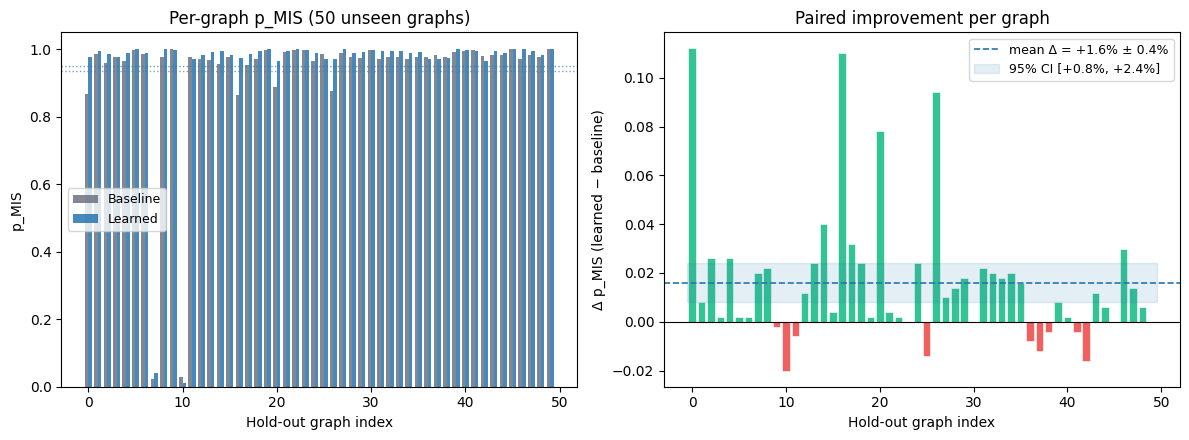

In [13]:
from tqdm.auto import tqdm
from scipy import stats

# ── Hold-out protocol ─────────────────────────────────────────────────
N_HOLDOUT = 50
N_SHOTS_HOLDOUT = 500          # match training shot budget
EVAL_SEED_START = 1000         # training pool used seeds 100–107

def _sem(x):
    """Standard error of the mean across graphs."""
    x = np.asarray(x, dtype=float)
    return 0.0 if len(x) < 2 else float(np.std(x, ddof=1) / np.sqrt(len(x)))

def _fmt_pct(mean, err):
    return f"{100 * mean:.1f}% ± {100 * err:.1f}%"

# Build 50 fresh graphs (same 3×3 King's-lattice recipe as the training pool)
holdout = []
seed = EVAL_SEED_START
while len(holdout) < N_HOLDOUT:
    udg_h = UDGConfig(
        nx=3, ny=3, spacing=5.0, radius=1.5,
        dropout_rate=1/3, seed=seed,
    )
    G, pos = generate_square_lattice_udg(udg_h)
    seed += 1
    if G.number_of_edges() == 0:
        continue
    G.graph["positions"] = pos
    G.graph["seed"] = udg_h.seed
    holdout.append(G)

print(f"Hold-out set: {len(holdout)} graphs  "
      f"(seeds {holdout[0].graph['seed']}–{holdout[-1].graph['seed']}, "
      f"{N_SHOTS_HOLDOUT} shots/graph, 2 sim calls/graph)")

backend_holdout = BraketBackend(
    tiny_cfg, n_shots=N_SHOTS_HOLDOUT,
    backend_type="simulator", validate=True,
)

learned_ps, baseline_ps, deltas = [], [], []
per_graph = []

policy.eval()
pbar = tqdm(holdout, desc="Hold-out p_MIS", unit="graph", dynamic_ncols=True)

for G in pbar:
    pos = G.graph["positions"]
    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)

    res_l = backend_holdout.estimate_p_mis(sched_l, G, pos)
    res_b = backend_holdout.estimate_p_mis(sched_b, G, pos)

    learned_ps.append(res_l.p_mis)
    baseline_ps.append(res_b.p_mis)
    deltas.append(res_l.p_mis - res_b.p_mis)
    per_graph.append({
        "seed": G.graph["seed"],
        "n": G.number_of_nodes(),
        "p_learned": res_l.p_mis,
        "p_baseline": res_b.p_mis,
        "delta": res_l.p_mis - res_b.p_mis,
        "se_l": res_l.std_err or 0.0,
        "se_b": res_b.std_err or 0.0,
    })

    pbar.set_postfix(
        baseline=_fmt_pct(np.mean(baseline_ps), _sem(baseline_ps)),
        learned=_fmt_pct(np.mean(learned_ps), _sem(learned_ps)),
        delta=_fmt_pct(np.mean(deltas), _sem(deltas)),
        refresh=True,
    )

# ── Final statistics ──────────────────────────────────────────────────
n = len(deltas)
mean_b, sem_b = np.mean(baseline_ps), _sem(baseline_ps)
mean_l, sem_l = np.mean(learned_ps), _sem(learned_ps)
mean_d, sem_d = np.mean(deltas), _sem(deltas)

t_crit = stats.t.ppf(0.975, df=n - 1)
ci_lo, ci_hi = mean_d - t_crit * sem_d, mean_d + t_crit * sem_d

t_stat, p_two = stats.ttest_rel(learned_ps, baseline_ps)
try:
    w_stat, p_one = stats.wilcoxon(learned_ps, baseline_ps, alternative="greater")
except ValueError:
    w_stat, p_one = float("nan"), float("nan")

wins = sum(d > 0 for d in deltas)
ties = sum(abs(d) < 1e-12 for d in deltas)

print("\n" + "=" * 72)
print(f"HOLD-OUT RESULTS  ({n} graphs × {N_SHOTS_HOLDOUT} shots, unseen seeds)")
print("=" * 72)
print(f"  Baseline p_MIS : {_fmt_pct(mean_b, sem_b)}")
print(f"  Learned  p_MIS : {_fmt_pct(mean_l, sem_l)}")
print(f"  Δ (learned − baseline) : {_fmt_pct(mean_d, sem_d)}")
print(f"  95 % CI on Δ           : [{100*ci_lo:+.1f}%, {100*ci_hi:+.1f}%]")
print(f"  Win / tie / loss       : {wins} / {ties} / {n - wins - ties}")
print(f"  Paired t-test          : t = {t_stat:+.3f},  p(two-sided) = {p_two:.4f}")
print(f"  Wilcoxon (learned > baseline) : W = {w_stat:.1f},  p(one-sided) = {p_one:.4f}")
print("=" * 72)

# ── Summary figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x = np.arange(n)
width = 0.38
ax.bar(x - width / 2, baseline_ps, width, color="#6b7280", alpha=0.85, label="Baseline")
ax.bar(x + width / 2, learned_ps, width, color="#2774AE", alpha=0.85, label="Learned")
ax.axhline(mean_b, color="#6b7280", linestyle=":", linewidth=1.0, alpha=0.7)
ax.axhline(mean_l, color="#2774AE", linestyle=":", linewidth=1.0, alpha=0.7)
ax.set_xlabel("Hold-out graph index")
ax.set_ylabel("p_MIS")
ax.set_title(f"Per-graph p_MIS ({n} unseen graphs)")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

ax = axes[1]
colors = ["#10B981" if d > 0 else "#EF4444" if d < 0 else "#6b7280" for d in deltas]
ax.bar(x, deltas, color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(mean_d, color="#2774AE", linestyle="--", linewidth=1.2,
           label=f"mean Δ = {100*mean_d:+.1f}% ± {100*sem_d:.1f}%")
ax.fill_between([-0.5, n - 0.5], ci_lo, ci_hi, color="#2774AE", alpha=0.12,
                label=f"95% CI [{100*ci_lo:+.1f}%, {100*ci_hi:+.1f}%]")
ax.set_xlabel("Hold-out graph index")
ax.set_ylabel("Δ p_MIS (learned − baseline)")
ax.set_title("Paired improvement per graph")
ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()

## 10. Large hold-out evaluation — 100 unseen graphs → `results.csv`

Same protocol as §9 but on **100 fresh graphs** (seeds starting at 2000, disjoint from both the training pool and the §9 hold-out). Results are written to **`results.csv`** at the repo root (one row per graph, plus a summary block at the bottom).

In [14]:
import csv
from pathlib import Path
from tqdm.auto import tqdm
from scipy import stats

def _sem(x):
    x = np.asarray(x, dtype=float)
    return 0.0 if len(x) < 2 else float(np.std(x, ddof=1) / np.sqrt(len(x)))

def _fmt_pct(mean, err):
    return f"{100 * mean:.1f}% ± {100 * err:.1f}%"

# ── Large hold-out protocol ───────────────────────────────────────────
N_HOLDOUT_LARGE = 100
N_SHOTS_LARGE = 500
EVAL_SEED_LARGE = 2000        # §9 used 1000–1049; training pool used 100–107
RESULTS_CSV = Path("..").resolve() / "results.csv"

# Build 100 fresh graphs
holdout_large = []
seed = EVAL_SEED_LARGE
while len(holdout_large) < N_HOLDOUT_LARGE:
    udg_h = UDGConfig(
        nx=3, ny=3, spacing=5.0, radius=1.5,
        dropout_rate=1/3, seed=seed,
    )
    G, pos = generate_square_lattice_udg(udg_h)
    seed += 1
    if G.number_of_edges() == 0:
        continue
    G.graph["positions"] = pos
    G.graph["seed"] = udg_h.seed
    holdout_large.append(G)

print(f"Large hold-out: {len(holdout_large)} graphs  "
      f"(seeds {holdout_large[0].graph['seed']}–{holdout_large[-1].graph['seed']}, "
      f"{N_SHOTS_LARGE} shots/graph)")
print(f"Results will be saved to: {RESULTS_CSV}")

backend_large = BraketBackend(
    tiny_cfg, n_shots=N_SHOTS_LARGE,
    backend_type="simulator", validate=True,
)

learned_lg, baseline_lg, deltas_lg = [], [], []
rows = []

policy.eval()
pbar = tqdm(holdout_large, desc="Hold-out 100", unit="graph", dynamic_ncols=True)

for idx, G in enumerate(pbar):
    pos = G.graph["positions"]
    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)

    res_l = backend_large.estimate_p_mis(sched_l, G, pos)
    res_b = backend_large.estimate_p_mis(sched_b, G, pos)

    p_l, p_b = res_l.p_mis, res_b.p_mis
    delta = p_l - p_b
    learned_lg.append(p_l)
    baseline_lg.append(p_b)
    deltas_lg.append(delta)

    rows.append({
        "graph_idx": idx,
        "seed": G.graph["seed"],
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "shots": N_SHOTS_LARGE,
        "p_baseline": p_b,
        "p_learned": p_l,
        "delta": delta,
        "se_baseline": res_b.std_err or 0.0,
        "se_learned": res_l.std_err or 0.0,
    })

    pbar.set_postfix(
        baseline=_fmt_pct(np.mean(baseline_lg), _sem(baseline_lg)),
        learned=_fmt_pct(np.mean(learned_lg), _sem(learned_lg)),
        delta=_fmt_pct(np.mean(deltas_lg), _sem(deltas_lg)),
        refresh=True,
    )

# ── Aggregate statistics ──────────────────────────────────────────────
n_lg = len(deltas_lg)
mean_b_lg, sem_b_lg = np.mean(baseline_lg), _sem(baseline_lg)
mean_l_lg, sem_l_lg = np.mean(learned_lg), _sem(learned_lg)
mean_d_lg, sem_d_lg = np.mean(deltas_lg), _sem(deltas_lg)

t_crit_lg = stats.t.ppf(0.975, df=n_lg - 1)
ci_lo_lg = mean_d_lg - t_crit_lg * sem_d_lg
ci_hi_lg = mean_d_lg + t_crit_lg * sem_d_lg

t_stat_lg, p_two_lg = stats.ttest_rel(learned_lg, baseline_lg)
try:
    w_stat_lg, p_one_lg = stats.wilcoxon(learned_lg, baseline_lg, alternative="greater")
except ValueError:
    w_stat_lg, p_one_lg = float("nan"), float("nan")

wins_lg = sum(d > 0 for d in deltas_lg)
ties_lg = sum(abs(d) < 1e-12 for d in deltas_lg)

# ── Write results.csv ─────────────────────────────────────────────────
fieldnames = [
    "graph_idx", "seed", "n_nodes", "n_edges", "shots",
    "p_baseline", "p_learned", "delta", "se_baseline", "se_learned",
]

summary_rows = [
    {"graph_idx": "SUMMARY_mean", "p_baseline": mean_b_lg, "p_learned": mean_l_lg,
     "delta": mean_d_lg, "se_baseline": sem_b_lg, "se_learned": sem_l_lg,
     "n_nodes": n_lg, "shots": N_SHOTS_LARGE},
    {"graph_idx": "SUMMARY_ci95_delta_lo", "delta": ci_lo_lg},
    {"graph_idx": "SUMMARY_ci95_delta_hi", "delta": ci_hi_lg},
    {"graph_idx": "SUMMARY_p_ttest_two_sided", "delta": p_two_lg},
    {"graph_idx": "SUMMARY_p_wilcoxon_one_sided", "delta": p_one_lg},
    {"graph_idx": "SUMMARY_wins", "delta": wins_lg},
    {"graph_idx": "SUMMARY_ties", "delta": ties_lg},
    {"graph_idx": "SUMMARY_losses", "delta": n_lg - wins_lg - ties_lg},
]

with open(RESULTS_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(rows)
    writer.writerows(summary_rows)

print(f"\nSaved {len(rows)} per-graph rows + {len(summary_rows)} summary rows to {RESULTS_CSV}")

print("\n" + "=" * 72)
print(f"LARGE HOLD-OUT  ({n_lg} graphs × {N_SHOTS_LARGE} shots, seeds ≥ {EVAL_SEED_LARGE})")
print("=" * 72)
print(f"  Baseline p_MIS : {_fmt_pct(mean_b_lg, sem_b_lg)}")
print(f"  Learned  p_MIS : {_fmt_pct(mean_l_lg, sem_l_lg)}")
print(f"  Δ (learned − baseline) : {_fmt_pct(mean_d_lg, sem_d_lg)}")
print(f"  95 % CI on Δ           : [{100*ci_lo_lg:+.1f}%, {100*ci_hi_lg:+.1f}%]")
print(f"  Win / tie / loss       : {wins_lg} / {ties_lg} / {n_lg - wins_lg - ties_lg}")
print(f"  Paired t-test          : t = {t_stat_lg:+.3f},  p(two-sided) = {p_two_lg:.4f}")
print(f"  Wilcoxon (learned > baseline) : W = {w_stat_lg:.1f},  p(one-sided) = {p_one_lg:.4f}")
print("=" * 72)

Large hold-out: 100 graphs  (seeds 2000–2099, 500 shots/graph)
Results will be saved to: /Users/alexanderjurgens/Documents/git_repos/MIS_Neutral_Atoms/results.csv


Hold-out 100:   0%|          | 0/100 [00:00<?, ?graph/s]

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s


Hold-out 100:   1%|          | 1/100 [00:02<03:49,  2.32s/graph, baseline=97.4% ± 0.0%, delta=2.2% ± 0.0%, learned=99.6% ± 0.0%]

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.4 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.3 s


...

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.1 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s


Hold-out 100:  99%|█████████▉| 99/100 [03:41<00:02,  2.37s/graph, baseline=97.0% ± 0.3%, delta=1.9% ± 0.3%, learned=98.9% ± 0.1%]

BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s
BraketBackend: running LocalSimulator — 500 shots, blockade_radius=8.4 μm …
BraketBackend: done in 1.2 s


Hold-out 100: 100%|██████████| 100/100 [03:44<00:00,  2.24s/graph, baseline=96.9% ± 0.3%, delta=2.0% ± 0.3%, learned=98.9% ± 0.1%]


Saved 100 per-graph rows + 8 summary rows to /Users/alexanderjurgens/Documents/git_repos/MIS_Neutral_Atoms/results.csv

LARGE HOLD-OUT  (100 graphs × 500 shots, seeds ≥ 2000)
  Baseline p_MIS : 96.9% ± 0.3%
  Learned  p_MIS : 98.9% ± 0.1%
  Δ (learned − baseline) : 2.0% ± 0.3%
  95 % CI on Δ           : [+1.4%, +2.5%]
  Win / tie / loss       : 75 / 6 / 19
  Paired t-test          : t = +6.666,  p(two-sided) = 0.0000
  Wilcoxon (learned > baseline) : W = 4019.0,  p(one-sided) = 0.0000


## 11. Scaling study — 2× graph size (50 graphs)

Compare hold-out performance when graphs have **roughly twice as many atoms** as §9/§10 (4×4 lattice with the same King's-graph connectivity recipe, yielding ~11 nodes vs ~6). Split into a **specs** cell and a **run** cell below.

In [ ]:
# ── Experiment specs (§9, §10, §11) ───────────────────────────────────
# Shared graph / hardware recipe (all hold-outs)
_SHARED = dict(spacing=5.0, radius=1.5, dropout_rate=1/3)   # King's lattice
_SHOTS = 500

# Quick reference sizes (deterministic dropout count)
def _expected_nodes(nx, ny, dropout):
    n_tot = nx * ny
    return n_tot - int(round(dropout * n_tot))

experiments = [
    {
        "section": "§9  (hold-out)",
        "n_graphs": 50,
        "lattice": "3 × 3",
        "expected_nodes": _expected_nodes(3, 3, 1/3),
        "seed_range": "1000 – 1049",
        "shots_per_graph": _SHOTS,
        "sim_calls_per_graph": 2,
        "output": "console + figure",
        "notes": "First unseen hold-out; same size as training pool",
    },
    {
        "section": "§10 (large hold-out)",
        "n_graphs": 100,
        "lattice": "3 × 3",
        "expected_nodes": _expected_nodes(3, 3, 1/3),
        "seed_range": "2000 – 2099",
        "shots_per_graph": _SHOTS,
        "sim_calls_per_graph": 2,
        "output": "results.csv",
        "notes": "2× graph count, same per-graph size",
    },
    {
        "section": "§11 (scaling 2×)",
        "n_graphs": 50,
        "lattice": "4 × 4",
        "expected_nodes": _expected_nodes(4, 4, 1/3),
        "seed_range": "3000 – 3049",
        "shots_per_graph": _SHOTS,
        "sim_calls_per_graph": 2,
        "output": "results_scaling.csv",
        "notes": "~2× nodes; policy trained on 6-atom graphs (OOD test)",
    },
]

print("=" * 88)
print("HOLD-OUT / SCALING EXPERIMENT MATRIX")
print("=" * 88)
print(f"  Shared connectivity : spacing={_SHARED['spacing']} μm, "
      f"radius={_SHARED['radius']} (King's), dropout={_SHARED['dropout_rate']:.2f}")
print(f"  Policy training size: 3×3 lattice → {_expected_nodes(3,3,1/3)} nodes "
      f"(seeds 100–107)")
print()

header = (
    f"{'Section':<22} {'#G':>4} {'Lattice':>8} {'~Nodes':>7} "
    f"{'Seeds':>14} {'Shots':>6} {'Output':>22}"
)
print(header)
print("-" * len(header))
for ex in experiments:
    print(
        f"{ex['section']:<22} {ex['n_graphs']:>4} {ex['lattice']:>8} "
        f"{ex['expected_nodes']:>7} {ex['seed_range']:>14} "
        f"{ex['shots_per_graph']:>6} {ex['output']:>22}"
    )

print()
print("Notes:")
for ex in experiments:
    sec_per_call = 1.5 if ex["expected_nodes"] <= 8 else 8.0   # §11 is much slower
    est_runtime = ex["n_graphs"] * ex["sim_calls_per_graph"] * sec_per_call
    print(f"  • {ex['section']}: {ex['notes']}")
    print(f"      est. simulator time ≈ {est_runtime/60:.1f} min "
          f"({ex['n_graphs']}×2 calls @ ~{sec_per_call:.0f} s/call)")

print()
print("§11 scaling factor:")
n_small = _expected_nodes(3, 3, 1/3)
n_large = _expected_nodes(4, 4, 1/3)
print(f"  nodes: {n_small} → {n_large}  ({n_large/n_small:.2f}×)")
print(f"  Hilbert dim: 2^{n_small} → 2^{n_large}  ({2**n_large / 2**n_small:.0f}×)")
print("=" * 88)

In [ ]:
import csv
from pathlib import Path
from tqdm.auto import tqdm
from scipy import stats

def _sem(x):
    x = np.asarray(x, dtype=float)
    return 0.0 if len(x) < 2 else float(np.std(x, ddof=1) / np.sqrt(len(x)))

def _fmt_pct(mean, err):
    return f"{100 * mean:.1f}% ± {100 * err:.1f}%"

# ── §11 scaling run: 4×4 lattice (~2× nodes) ─────────────────────────
N_SCALING = 50
N_SHOTS_SCALING = 500
EVAL_SEED_SCALING = 3000
SCALING_NX, SCALING_NY = 4, 4
RESULTS_SCALING_CSV = Path("..").resolve() / "results_scaling.csv"

holdout_scale = []
seed = EVAL_SEED_SCALING
while len(holdout_scale) < N_SCALING:
    udg_s = UDGConfig(
        nx=SCALING_NX, ny=SCALING_NY,
        spacing=5.0, radius=1.5,
        dropout_rate=1/3, seed=seed,
    )
    G, pos = generate_square_lattice_udg(udg_s)
    seed += 1
    if G.number_of_edges() == 0:
        continue
    G.graph["positions"] = pos
    G.graph["seed"] = udg_s.seed
    holdout_scale.append(G)

nodes = [g.number_of_nodes() for g in holdout_scale]
edges = [g.number_of_edges() for g in holdout_scale]
print(f"Scaling hold-out: {len(holdout_scale)} graphs  "
      f"(seeds {holdout_scale[0].graph['seed']}–{holdout_scale[-1].graph['seed']})")
print(f"  lattice {SCALING_NX}×{SCALING_NY}  |  nodes: "
      f"mean={np.mean(nodes):.1f} (min={min(nodes)}, max={max(nodes)})  |  "
      f"edges: mean={np.mean(edges):.1f}")
print(f"  {N_SHOTS_SCALING} shots/graph  →  {RESULTS_SCALING_CSV}")

backend_scale = BraketBackend(
    tiny_cfg, n_shots=N_SHOTS_SCALING,
    backend_type="simulator", validate=True,
)

learned_sc, baseline_sc, deltas_sc = [], [], []
rows_sc = []

policy.eval()
pbar = tqdm(holdout_scale, desc="Scaling 2×", unit="graph", dynamic_ncols=True)

for idx, G in enumerate(pbar):
    pos = G.graph["positions"]
    sched_l = policy.make_schedule(G)
    sched_b = baseline_model.make_schedule(G)

    res_l = backend_scale.estimate_p_mis(sched_l, G, pos)
    res_b = backend_scale.estimate_p_mis(sched_b, G, pos)

    p_l, p_b = res_l.p_mis, res_b.p_mis
    delta = p_l - p_b
    learned_sc.append(p_l)
    baseline_sc.append(p_b)
    deltas_sc.append(delta)

    rows_sc.append({
        "graph_idx": idx,
        "seed": G.graph["seed"],
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "shots": N_SHOTS_SCALING,
        "p_baseline": p_b,
        "p_learned": p_l,
        "delta": delta,
        "se_baseline": res_b.std_err or 0.0,
        "se_learned": res_l.std_err or 0.0,
    })

    pbar.set_postfix(
        baseline=_fmt_pct(np.mean(baseline_sc), _sem(baseline_sc)),
        learned=_fmt_pct(np.mean(learned_sc), _sem(learned_sc)),
        delta=_fmt_pct(np.mean(deltas_sc), _sem(deltas_sc)),
        refresh=True,
    )

# ── Statistics ────────────────────────────────────────────────────────
n_sc = len(deltas_sc)
mean_b_sc, sem_b_sc = np.mean(baseline_sc), _sem(baseline_sc)
mean_l_sc, sem_l_sc = np.mean(learned_sc), _sem(learned_sc)
mean_d_sc, sem_d_sc = np.mean(deltas_sc), _sem(deltas_sc)

t_crit_sc = stats.t.ppf(0.975, df=n_sc - 1)
ci_lo_sc = mean_d_sc - t_crit_sc * sem_d_sc
ci_hi_sc = mean_d_sc + t_crit_sc * sem_d_sc

t_stat_sc, p_two_sc = stats.ttest_rel(learned_sc, baseline_sc)
try:
    w_stat_sc, p_one_sc = stats.wilcoxon(learned_sc, baseline_sc, alternative="greater")
except ValueError:
    w_stat_sc, p_one_sc = float("nan"), float("nan")

wins_sc = sum(d > 0 for d in deltas_sc)
ties_sc = sum(abs(d) < 1e-12 for d in deltas_sc)

# ── Save results_scaling.csv ──────────────────────────────────────────
fieldnames = [
    "graph_idx", "seed", "n_nodes", "n_edges", "shots",
    "p_baseline", "p_learned", "delta", "se_baseline", "se_learned",
]
summary_sc = [
    {"graph_idx": "SUMMARY_mean", "p_baseline": mean_b_sc, "p_learned": mean_l_sc,
     "delta": mean_d_sc, "se_baseline": sem_b_sc, "se_learned": sem_l_sc,
     "n_nodes": n_sc, "shots": N_SHOTS_SCALING},
    {"graph_idx": "SUMMARY_ci95_delta_lo", "delta": ci_lo_sc},
    {"graph_idx": "SUMMARY_ci95_delta_hi", "delta": ci_hi_sc},
    {"graph_idx": "SUMMARY_p_ttest_two_sided", "delta": p_two_sc},
    {"graph_idx": "SUMMARY_p_wilcoxon_one_sided", "delta": p_one_sc},
    {"graph_idx": "SUMMARY_wins", "delta": wins_sc},
    {"graph_idx": "SUMMARY_ties", "delta": ties_sc},
    {"graph_idx": "SUMMARY_losses", "delta": n_sc - wins_sc - ties_sc},
    {"graph_idx": "SUMMARY_lattice", "seed": f"{SCALING_NX}x{SCALING_NY}"},
    {"graph_idx": "SUMMARY_mean_n_nodes", "n_nodes": float(np.mean(nodes))},
]

with open(RESULTS_SCALING_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(rows_sc)
    writer.writerows(summary_sc)

print(f"\nSaved {len(rows_sc)} rows + summary to {RESULTS_SCALING_CSV}")
print("\n" + "=" * 72)
print(f"SCALING HOLD-OUT  ({n_sc} graphs × {N_SHOTS_SCALING} shots, "
      f"{SCALING_NX}×{SCALING_NY} lattice)")
print("=" * 72)
_n_small = 9 - int(round((1/3) * 9))   # 3×3 lattice, same dropout as §9/§10
print(f"  Mean |V|       : {np.mean(nodes):.1f} nodes  "
      f"(§9/§10 baseline: ~{_n_small} nodes)")
print(f"  Baseline p_MIS : {_fmt_pct(mean_b_sc, sem_b_sc)}")
print(f"  Learned  p_MIS : {_fmt_pct(mean_l_sc, sem_l_sc)}")
print(f"  Δ (learned − baseline) : {_fmt_pct(mean_d_sc, sem_d_sc)}")
print(f"  95 % CI on Δ           : [{100*ci_lo_sc:+.1f}%, {100*ci_hi_sc:+.1f}%]")
print(f"  Win / tie / loss       : {wins_sc} / {ties_sc} / {n_sc - wins_sc - ties_sc}")
print(f"  Paired t-test          : t = {t_stat_sc:+.3f},  p(two-sided) = {p_two_sc:.4f}")
print(f"  Wilcoxon (learned > baseline) : W = {w_stat_sc:.1f},  p(one-sided) = {p_one_sc:.4f}")
print("=" * 72)

# ── Quick comparison plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
x = np.arange(n_sc)
w = 0.38
ax.bar(x - w/2, baseline_sc, w, color="#6b7280", alpha=0.85, label="Baseline")
ax.bar(x + w/2, learned_sc, w, color="#2774AE", alpha=0.85, label="Learned")
ax.axhline(mean_b_sc, color="#6b7280", linestyle=":", lw=1)
ax.axhline(mean_l_sc, color="#2774AE", linestyle=":", lw=1)
ax.set_xlabel("Graph index")
ax.set_ylabel("p_MIS")
ax.set_title(f"§11 scaling: {SCALING_NX}×{SCALING_NY} (~{np.mean(nodes):.0f} nodes)")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

ax = axes[1]
colors = ["#10B981" if d > 0 else "#EF4444" if d < 0 else "#6b7280" for d in deltas_sc]
ax.bar(x, deltas_sc, color=colors, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.axhline(mean_d_sc, color="#2774AE", linestyle="--", lw=1.2,
           label=f"mean Δ = {100*mean_d_sc:+.1f}% ± {100*sem_d_sc:.1f}%")
ax.fill_between([-0.5, n_sc - 0.5], ci_lo_sc, ci_hi_sc,
                color="#2774AE", alpha=0.12, label="95% CI")
ax.set_xlabel("Graph index")
ax.set_ylabel("Δ p_MIS")
ax.set_title("Paired improvement (2× size)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()